In [1]:
import pandas as pd

df = pd.read_csv("../data/180822-agt-cierre-2013.csv", encoding="latin-1")
df.head()

,AñoAgricola,CveEstado,Estado,CveDDR,DDR,CveCader,Cader,CveMpio,Municipio,CveCultivo,...,Ciclo,CveModa,Modalidad,Sembrada,Cosechada,Siniestrada,Produccion,Rendimiento,Pmr,Valor
0,2013,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,500,...,PERENNES,2,TEMPORAL,241,0,241,0,0,0,0
1,2013,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,700,...,OTOÑO-INVIERNO,1,RIEGO,2,2,0,22,11,"9,000","198,000"
2,2013,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,1500,...,PERENNES,1,RIEGO,"1,900","1,900",0,"186,454.80",98.134,706.68,"131,763,878.06"
3,2013,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,3900,...,OTOÑO-INVIERNO,1,RIEGO,798,798,0,"21,181",26.543,603.77,"12,788,452.37"
4,2013,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,1,AGUASCALIENTES,3900,...,PRIMAVERA-VERANO,2,TEMPORAL,313,313,0,"2,497",7.978,470.28,"1,174,289.16"


In [2]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39937 entries, 0 to 39936
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   AñoAgricola   39937 non-null  int64
 1   CveEstado     39937 non-null  int64
 2   Estado        39937 non-null  str  
 3   CveDDR        39937 non-null  int64
 4   DDR           39937 non-null  str  
 5   CveCader      39937 non-null  int64
 6   Cader         39937 non-null  str  
 7   CveMpio       39937 non-null  int64
 8   Municipio     39937 non-null  str  
 9   CveCultivo    39937 non-null  int64
 10  Cultivo       39937 non-null  str  
 11  CveVariedad   39937 non-null  int64
 12  Variedad      23297 non-null  str  
 13  CveUnidad     39937 non-null  int64
 14  UnidadMedida  39937 non-null  str  
 15  CveCiclo      39937 non-null  int64
 16  Ciclo         39937 non-null  str  
 17  CveModa       39937 non-null  int64
 18  Modalidad     39937 non-null  str  
 19  Sembrada      39937 non-null  str  


In [3]:
df[["Sembrada", "Produccion", "Valor"]].head(10)

,Sembrada,Produccion,Valor
0,241,0,0
1,2,22,"198,000"
2,"1,900","186,454.80","131,763,878.06"
3,798,"21,181","12,788,452.37"
4,313,"2,497","1,174,289.16"
5,6,112,"445,200"
6,26,468,"702,000"
7,43,387,"2,322,000"
8,11,89,"469,400.24"
9,102,293,"2,930,000"


In [4]:
df = pd.read_csv("../data/180822-agt-cierre-2013.csv", encoding="latin-1", thousands=",")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39937 entries, 0 to 39936
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AñoAgricola   39937 non-null  int64  
 1   CveEstado     39937 non-null  int64  
 2   Estado        39937 non-null  str    
 3   CveDDR        39937 non-null  int64  
 4   DDR           39937 non-null  str    
 5   CveCader      39937 non-null  int64  
 6   Cader         39937 non-null  str    
 7   CveMpio       39937 non-null  int64  
 8   Municipio     39937 non-null  str    
 9   CveCultivo    39937 non-null  int64  
 10  Cultivo       39937 non-null  str    
 11  CveVariedad   39937 non-null  int64  
 12  Variedad      23297 non-null  str    
 13  CveUnidad     39937 non-null  int64  
 14  UnidadMedida  39937 non-null  str    
 15  CveCiclo      39937 non-null  int64  
 16  Ciclo         39937 non-null  str    
 17  CveModa       39937 non-null  int64  
 18  Modalidad     39937 non-null  str    

In [5]:
sinaloa = df[df["Estado"].str.contains("Sinaloa", case=False)]
sinaloa.shape

(939, 26)

In [6]:
sinaloa["Municipio"].nunique()

18

In [7]:
top_cultivos = (
    sinaloa.groupby("Cultivo")["Valor"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_cultivos

Cultivo
MAIZ GRANO                1.202667e+10
TOMATE ROJO (JITOMATE)    4.122429e+09
CHILE VERDE               3.264912e+09
PAPA                      2.626978e+09
SORGO GRANO               2.095426e+09
FRIJOL                    1.845668e+09
PEPINO                    1.836047e+09
GARBANZO GRANO            1.540953e+09
CAÑA DE AZUCAR            1.000028e+09
BERENJENA                 4.842704e+08
Name: Valor, dtype: float64

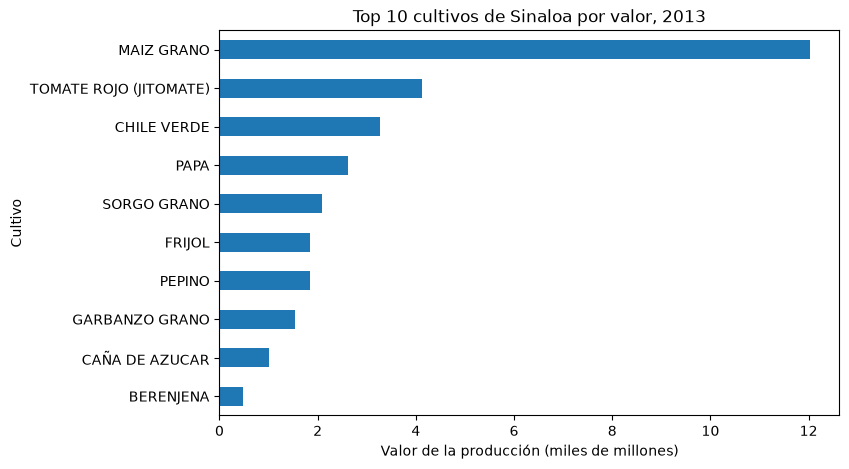

In [8]:
import matplotlib.pyplot as plt

top_mmdp = top_cultivos / 1e9   # miles de millones

top_mmdp.sort_values().plot(kind="barh", figsize=(8, 5))
plt.xlabel("Valor de la producción (miles de millones)")
plt.title("Top 10 cultivos de Sinaloa por valor, 2013")
plt.show()

In [9]:
df1 = pd.read_csv("../data/180822-agt-cierre-2011-2012.csv",encoding="latin-1", thousands=",")
df2 = pd.read_csv("../data/180822-agt-cierre-2013.csv",encoding="latin-1", thousands=",")

print(list(df1.columns) == list(df2.columns))

True


In [10]:
agro = pd.concat([df1, df2], ignore_index=True)
agro.shape

(118008, 26)

In [11]:
agro["AñoAgricola"].value_counts().sort_index()

AñoAgricola
2011    38881
2012    39190
2013    39937
Name: count, dtype: int64

In [12]:
sinaloa = agro[agro["Estado"].str.contains("Sinaloa", case=False)].copy()
sinaloa["AñoAgricola"].value_counts().sort_index()

AñoAgricola
2011    958
2012    956
2013    939
Name: count, dtype: int64

In [13]:
valor_anual = sinaloa.groupby("AñoAgricola")["Valor"].sum() / 1e9
valor_anual

AñoAgricola
2011    23.829761
2012    35.566629
2013    33.659476
Name: Valor, dtype: float64

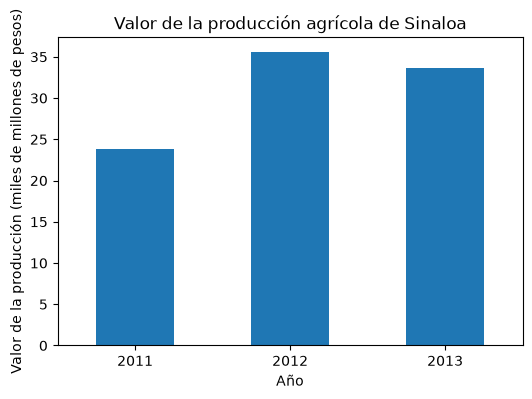

In [14]:
valor_anual.plot(kind="bar", figsize=(6, 4))
plt.ylabel("Valor de la producción (miles de millones de pesos)")
plt.xlabel("Año")
plt.title("Valor de la producción agrícola de Sinaloa")
plt.xticks(rotation=0)
plt.show()

In [15]:
sinaloa.groupby("AñoAgricola").agg(
    cultivos=("Cultivo", "nunique"),
    municipios=("Municipio", "nunique"),
    filas=("Cultivo", "size"),
)

,cultivos,municipios,filas
AñoAgricola,,,
2011,54,18,958
2012,57,18,956
2013,70,18,939


In [16]:
maiz = sinaloa[sinaloa["Cultivo"] == "MAIZ GRANO"]

resumen = maiz.groupby("AñoAgricola").agg(
    produccion=("Produccion", "sum"),
    valor=("Valor", "sum"),
)
resumen["precio_por_unidad"] = resumen["valor"] / resumen["produccion"]
resumen

,produccion,valor,precio_por_unidad
AñoAgricola,,,
2011,2929179.50,1.075383e+10,3671.278772
2012,3646875.26,1.472685e+10,4038.210298
2013,3627777.51,1.202667e+10,3315.160612


In [17]:
sinaloa.groupby("AñoAgricola")[["Sembrada", "Cosechada", "Siniestrada"]].sum()

,Sembrada,Cosechada,Siniestrada
AñoAgricola,,,
2011,1626540.58,978972.44,647568.14
2012,1180590.64,1115013.78,65576.86
2013,1208174.17,1075201.30,132972.87


In [18]:
maiz["UnidadMedida"].unique()

<StringArray>
['Tonelada']
Length: 1, dtype: str

In [19]:
hect = sinaloa.groupby("AñoAgricola")[["Sembrada", "Cosechada", "Siniestrada"]].sum()
hect["pct_siniestrada"] = hect["Siniestrada"] / hect["Sembrada"] * 100
hect.round(1)

,Sembrada,Cosechada,Siniestrada,pct_siniestrada
AñoAgricola,,,,
2011,1626540.6,978972.4,647568.1,39.8
2012,1180590.6,1115013.8,65576.9,5.6
2013,1208174.2,1075201.3,132972.9,11.0


In [20]:
s2011 = sinaloa[sinaloa["AñoAgricola"] == 2011]

por_cultivo = (
    s2011.groupby("Cultivo")[["Sembrada", "Siniestrada"]]
    .sum()
    .sort_values("Siniestrada", ascending=False)
    .head(10)
)
por_cultivo["pct_siniestrada"] = (por_cultivo["Siniestrada"] / por_cultivo["Sembrada"] * 100).round(1)
por_cultivo

,Sembrada,Siniestrada,pct_siniestrada
Cultivo,,,
MAIZ GRANO,837049.99,416497.80,49.8
FRIJOL,91140.80,50660.89,55.6
GARBANZO GRANO,46613.01,38206.68,82.0
SORGO GRANO,303857.25,36387.55,12.0
CARTAMO,30314.39,27604.72,91.1
AJONJOLÍ,50593.79,22657.05,44.8
TOMATE ROJO (JITOMATE),15399.18,7714.67,50.1
PASTOS Y PRADERAS EN VERDE,34281.00,6638.00,19.4
CHILE VERDE,16524.94,5717.25,34.6


In [21]:
por_mpio = (
    s2011.groupby("Municipio")[["Sembrada", "Siniestrada"]]
    .sum()
    .sort_values("Siniestrada", ascending=False)
)
por_mpio["pct_siniestrada"] = (por_mpio["Siniestrada"] / por_mpio["Sembrada"] * 100).round(1)
por_mpio

,Sembrada,Siniestrada,pct_siniestrada
Municipio,,,
GUASAVE,291674.07,137365.22,47.1
CULIACAN,236229.10,96482.40,40.8
NAVOLATO,160237.00,85442.00,53.3
AHOME,261370.50,82168.00,31.4
ANGOSTURA,121989.40,66219.50,54.3
SINALOA,117858.50,59176.43,50.2
MOCORITO,109698.50,41959.27,38.2
SALVADOR ALVARADO,53901.50,27854.84,51.7
EL FUERTE,49129.18,23935.00,48.7


In [22]:
por_ciclo = sinaloa.groupby(["AñoAgricola", "Ciclo"])[["Sembrada", "Siniestrada"]].sum()
por_ciclo["pct_siniestrada"] = (por_ciclo["Siniestrada"] / por_ciclo["Sembrada"] * 100).round(1)
por_ciclo

Sembrada  Siniestrada  pct_siniestrada
AñoAgricola Ciclo                                                     
2011        OTOÑO-INVIERNO    1262664.30    577496.04             45.7
            PERENNES           112375.41     15552.30             13.8
            PRIMAVERA-VERANO   251500.87     54519.80             21.7
2012        OTOÑO-INVIERNO     802545.27     29028.77              3.6
            PERENNES           100794.08      6850.74              6.8
            PRIMAVERA-VERANO   277251.29     29697.35             10.7
2013        OTOÑO-INVIERNO     831479.69     81361.87              9.8
            PERENNES           107036.66      7194.00              6.7
            PRIMAVERA-VERANO   269657.82     44417.00             16.5